<a href="https://www.kaggle.com/code/orxansmaylov92/africa-economic-banking-and-systemic-crisis-data?scriptVersionId=336491140" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [ ]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Model selection
from sklearn.model_selection import train_test_split

# Handling imbalanced data
from imblearn.over_sampling import SMOTE

# File handling
import os
from IPython.display import FileLink

In [ ]:
# Load the African economic crises dataset
# This dataset contains economic indicators and crisis events for African countries
df = pd.read_csv("/kaggle/input/africa-economic-banking-and-systemic-crisis-data/african_crises.csv")

In [ ]:
df.head()

,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis


In [ ]:
# Check for missing values in the dataset
df.isnull().sum()

case                               0
cc3                                0
country                            0
year                               0
systemic_crisis                    0
exch_usd                           0
domestic_debt_in_default           0
sovereign_external_debt_default    0
gdp_weighted_default               0
inflation_annual_cpi               0
independence                       0
currency_crises                    0
inflation_crises                   0
banking_crisis                     0
dtype: int64

In [ ]:
# Count the number of unique values in each column
# This helps us identify which columns are identifiers, categorical, or continuous
df.nunique()

case                                 13
cc3                                  13
country                              13
year                                155
systemic_crisis                       2
exch_usd                            772
domestic_debt_in_default              2
sovereign_external_debt_default       2
gdp_weighted_default                  6
inflation_annual_cpi               1022
independence                          2
currency_crises                       3
inflation_crises                      2
banking_crisis                        2
dtype: int64

In [ ]:
# Check unique values in the banking_crisis column
df["banking_crisis"].unique()
df['banking_crisis'].value_counts(normalize=True).round(2)

banking_crisis
no_crisis    0.91
crisis       0.09
Name: proportion, dtype: float64

In [ ]:
#  crisis 0, no_crisis 1-ə
df['banking_crisis'] = df['banking_crisis'].map({'no_crisis': 1, 'crisis': 0})
print("\nMappingdən sonra:")
print(df['banking_crisis'].value_counts(dropna=False))

# Integer-ə çevirərərk daha işlək hala gətirək
df['banking_crisis'] = df['banking_crisis'].astype(int)


Mappingdən sonra:
banking_crisis
1    965
0     94
Name: count, dtype: int64


In [ ]:
# Check the distribution of key crisis indicator columns
# This helps us understand the frequency of different types of crises and events

# List of columns to analyze
crisis_columns = [
    'systemic_crisis',
    'domestic_debt_in_default',
    'sovereign_external_debt_default',
    'independence',
    'currency_crises',
    'inflation_crises'
]

# Display value counts for each column
for column in crisis_columns:
    print(f"\n{column.upper()} Distribution:")
    print(df[column].value_counts())
    print("-" * 40)


SYSTEMIC_CRISIS Distribution:
systemic_crisis
0    977
1     82
Name: count, dtype: int64
----------------------------------------

DOMESTIC_DEBT_IN_DEFAULT Distribution:
domestic_debt_in_default
0    1017
1      42
Name: count, dtype: int64
----------------------------------------

SOVEREIGN_EXTERNAL_DEBT_DEFAULT Distribution:
sovereign_external_debt_default
0    897
1    162
Name: count, dtype: int64
----------------------------------------

INDEPENDENCE Distribution:
independence
1    822
0    237
Name: count, dtype: int64
----------------------------------------

CURRENCY_CRISES Distribution:
currency_crises
0    923
1    132
2      4
Name: count, dtype: int64
----------------------------------------

INFLATION_CRISES Distribution:
inflation_crises
0    922
1    137
Name: count, dtype: int64
----------------------------------------


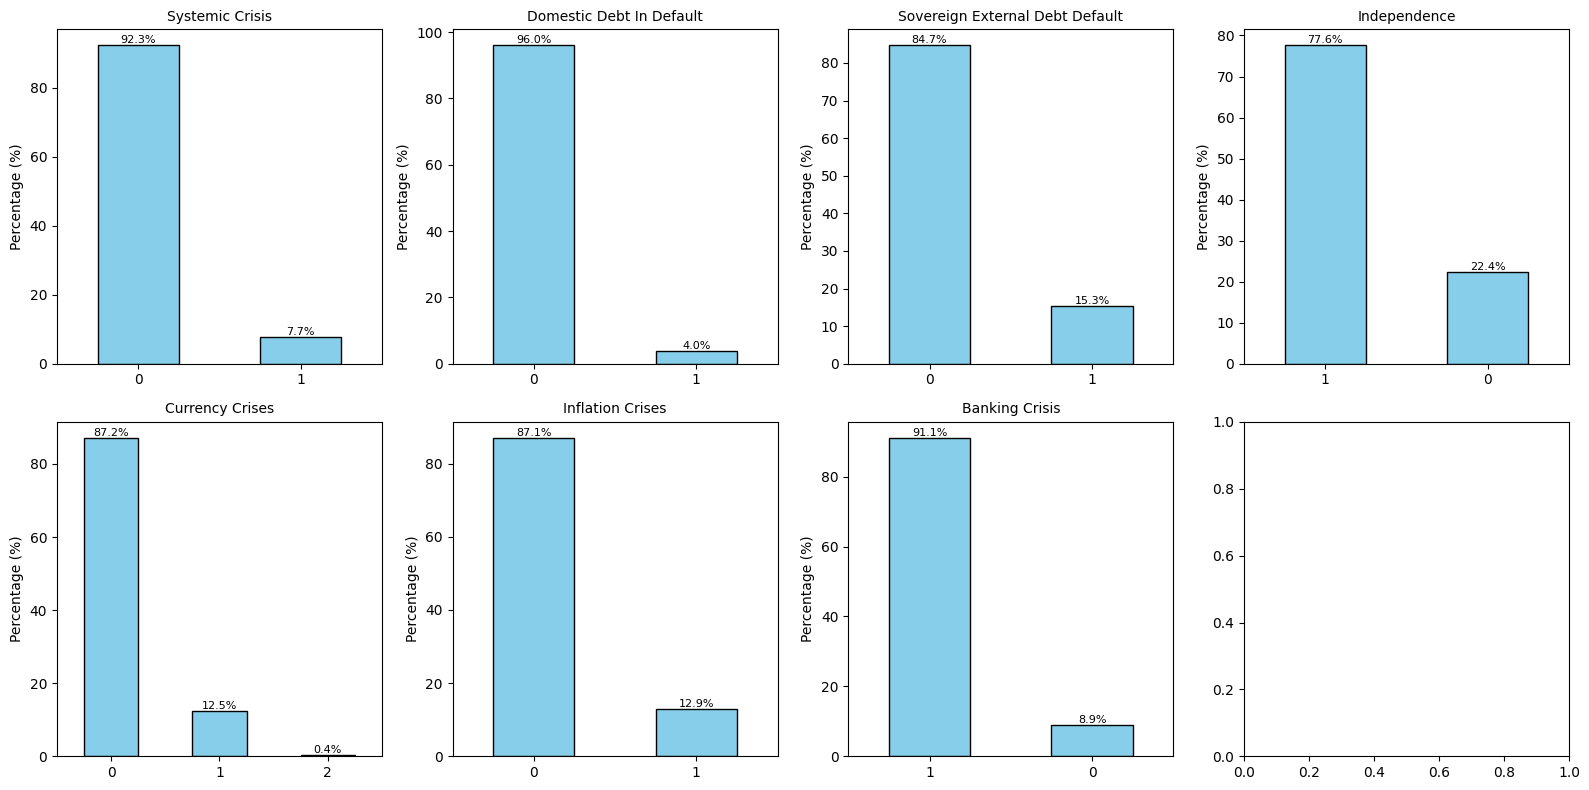

In [ ]:
# List of columns to visualize
crisis_columns = [
    'systemic_crisis',
    'domestic_debt_in_default',
    'sovereign_external_debt_default',
    'independence',
    'currency_crises',
    'inflation_crises',
    'banking_crisis'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(crisis_columns):
    # Calculate percentages
    percentages = df[col].value_counts(normalize=True) * 100

    # Create bar plot
    percentages.plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'{col.replace("_", " ").title()}', fontsize=10)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)

    # Add percentage labels on bars
    for j, p in enumerate(axes[i].patches):
        axes[i].annotate(f'{p.get_height():.1f}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Check unique values in the GDP-weighted default column
# This helps us understand the possible values and data distribution
gdp_weighted_unique = df['gdp_weighted_default'].unique()
print("Unique values in gdp_weighted_default:", gdp_weighted_unique)
print("Data type:", df['gdp_weighted_default'].dtype)

# Check value counts to see distribution
print("\nValue distribution:")
print(df['gdp_weighted_default'].value_counts())

Unique values in gdp_weighted_default: [0.   0.23 0.4  0.13 0.36 0.06]
Data type: float64

Value distribution:
gdp_weighted_default
0.00    1029
0.06       7
0.23       6
0.40       6
0.13       6
0.36       5
Name: count, dtype: int64


In [ ]:
# Find the highest GDP-weighted default indicators by country
# This helps us identify which countries have the most severe default events
# GDP-weighted default measures the economic impact of defaults relative to GDP

country_defaults = df.groupby('country')['gdp_weighted_default'].max().sort_values(ascending=False)

print("Countries and their highest GDP-weighted default indicators:")
print(country_defaults)

# Detailed view: Which country, which year, and how much?
detailed_view = df[df['gdp_weighted_default'] > 0][['country', 'year', 'gdp_weighted_default']].sort_values(by='gdp_weighted_default', ascending=False)
print("\nYears and countries where default was recorded:")
print(detailed_view.head(6))

Countries and their highest GDP-weighted default indicators:
country
Egypt                       0.40
South Africa                0.36
Algeria                     0.23
Morocco                     0.13
Tunisia                     0.06
Ivory Coast                 0.00
Central African Republic    0.00
Angola                      0.00
Kenya                       0.00
Nigeria                     0.00
Mauritius                   0.00
Zambia                      0.00
Zimbabwe                    0.00
Name: gdp_weighted_default, dtype: float64

Years and countries where default was recorded:
    country  year  gdp_weighted_default
407   Egypt  1984                   0.4
303   Egypt  1880                   0.4
302   Egypt  1879                   0.4
301   Egypt  1878                   0.4
300   Egypt  1877                   0.4
299   Egypt  1876                   0.4


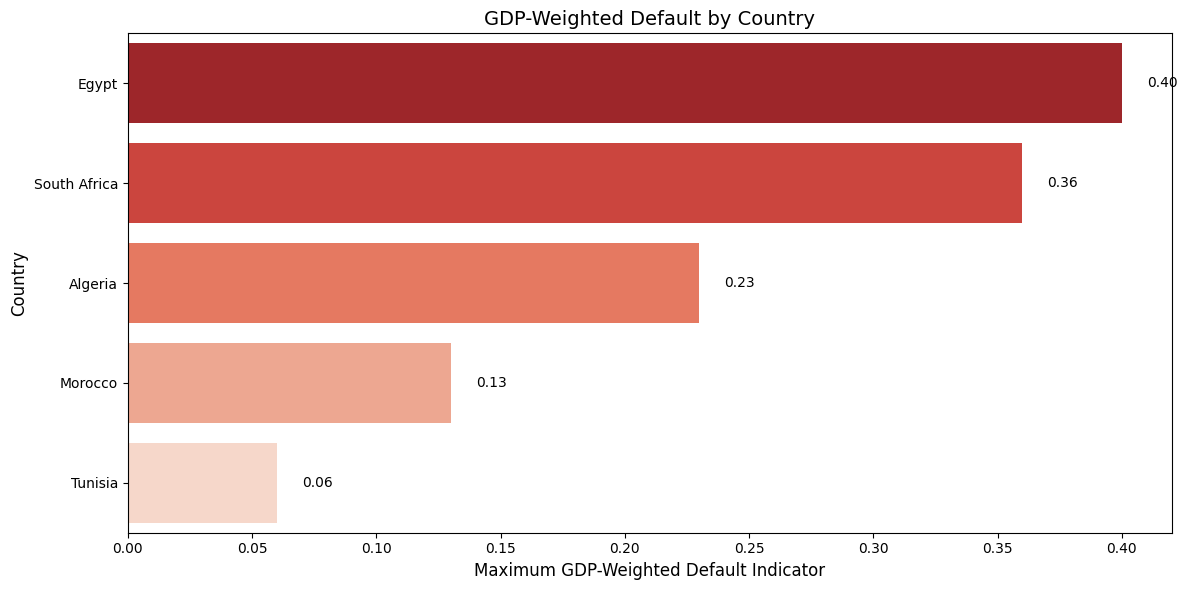

In [ ]:
# Calculate country default rates
country_defaults = df.groupby('country')['gdp_weighted_default'].max().sort_values(ascending=False)

# Filter for countries with default events > 0
country_defaults_filtered = country_defaults[country_defaults > 0]

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=country_defaults_filtered.values, y=country_defaults_filtered.index, hue=country_defaults_filtered.index, palette='Reds_r', legend=False)
plt.title('GDP-Weighted Default by Country', fontsize=14)
plt.xlabel('Maximum GDP-Weighted Default Indicator', fontsize=12)
plt.ylabel('Country', fontsize=12)

# Add value labels
for i, v in enumerate(country_defaults_filtered.values):
    plt.annotate(f'{v:.2f}', (v + 0.01, i), va='center', fontsize=10)

plt.tight_layout()
plt.show()

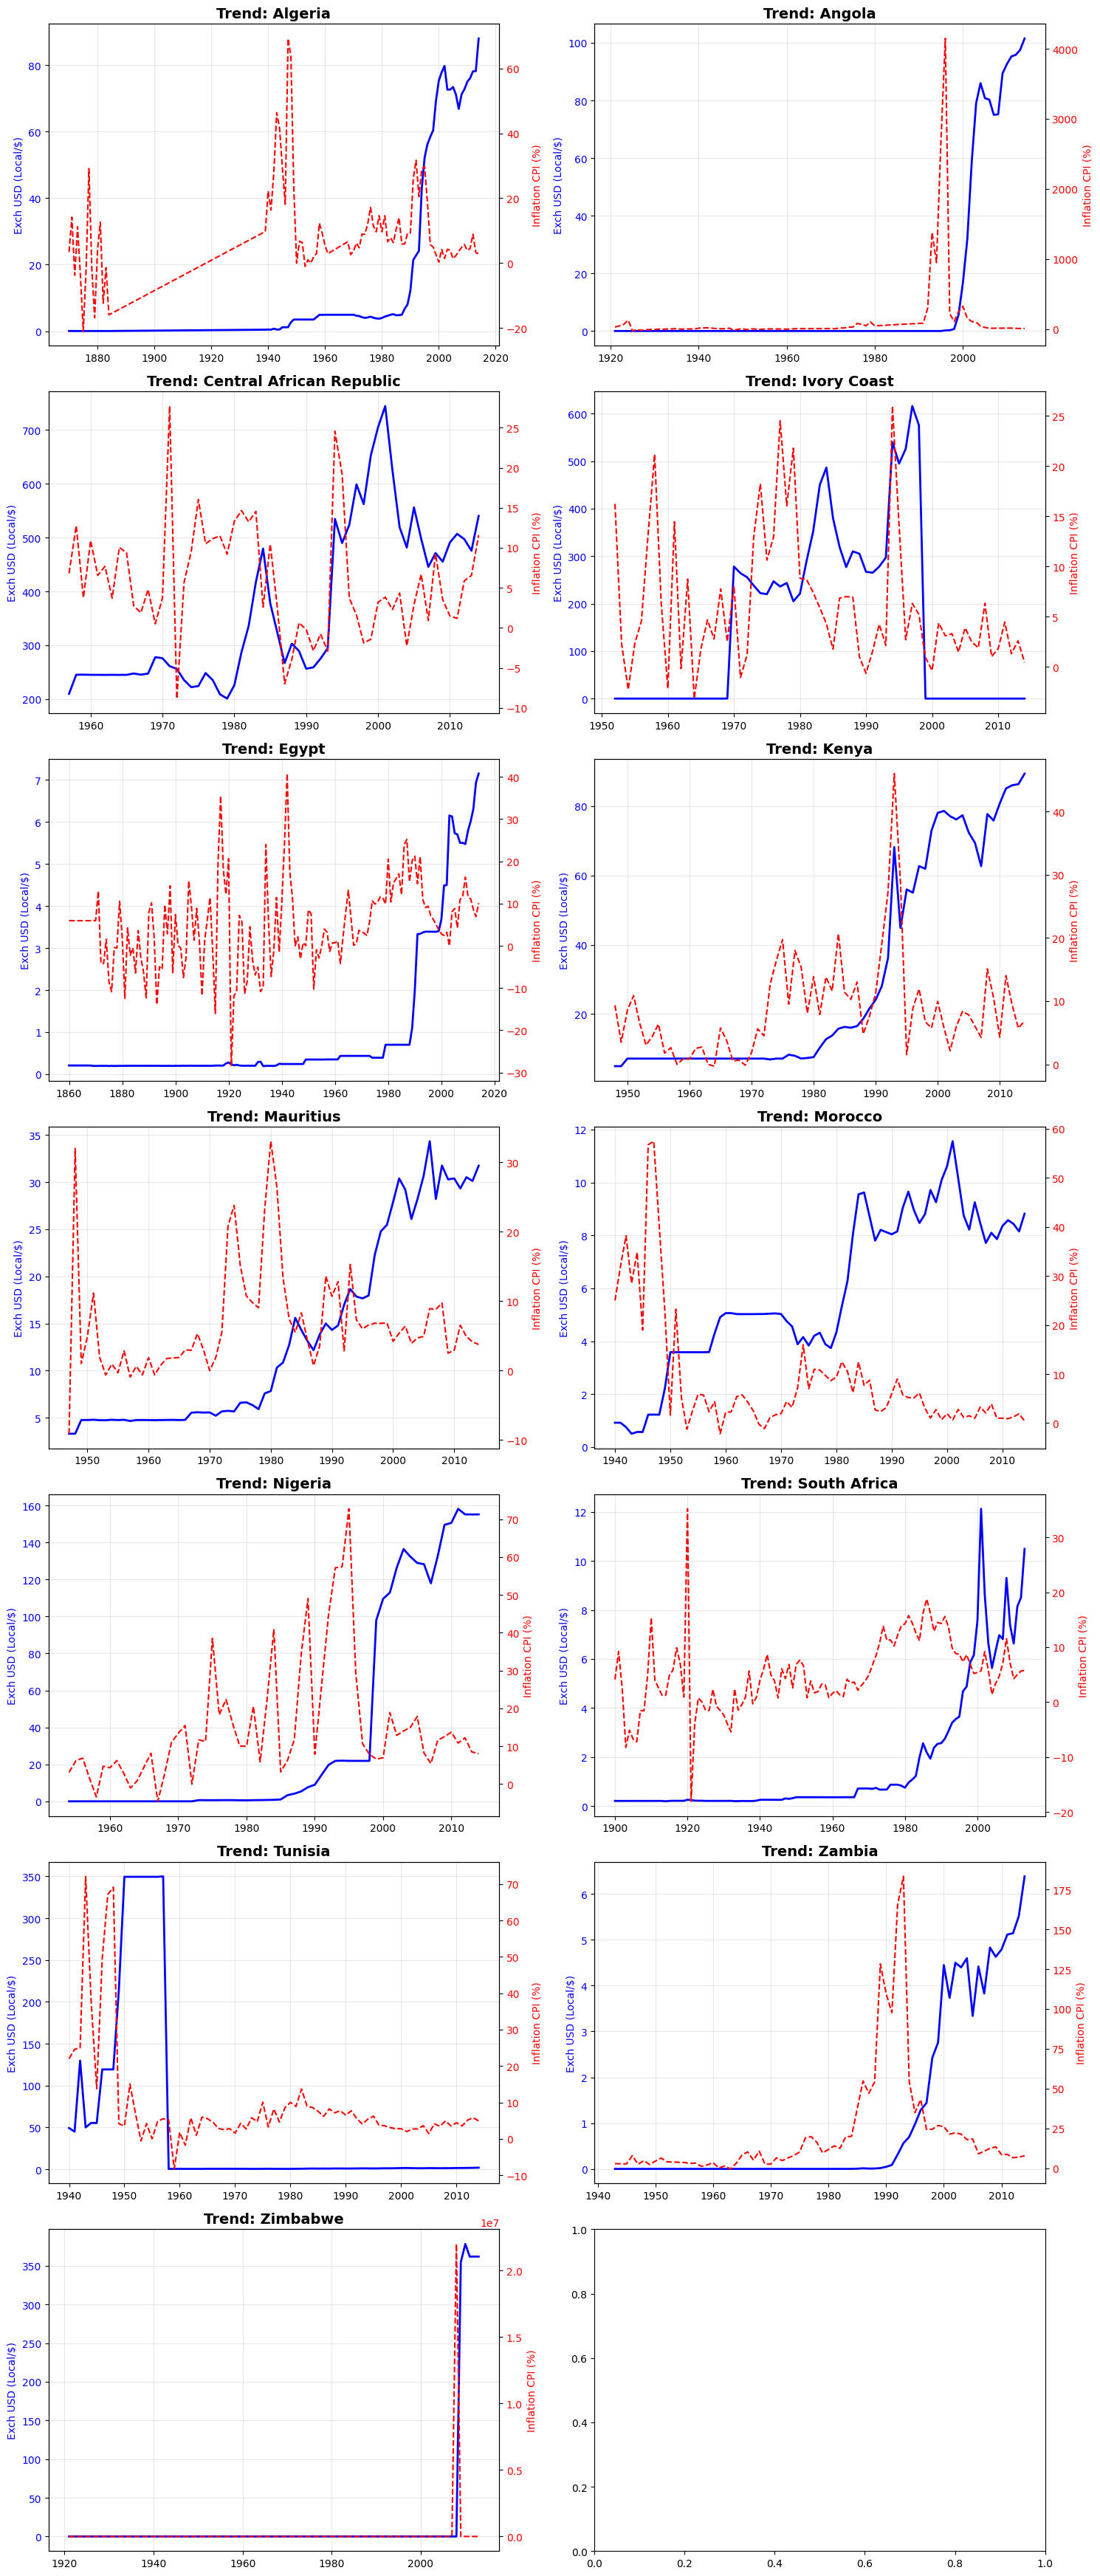

In [ ]:
# Visualize the dynamics of exchange rate and inflation for each country
countries = df['country'].unique()
n_countries = len(countries)

# Create subplots (7 rows, 2 columns for 13 countries)
fig, axes = plt.subplots(nrows=(n_countries + 1) // 2, ncols=2, figsize=(15, 35))
axes = axes.flatten()

for i, country in enumerate(countries):
    # Filter and sort data for the current country
    country_data = df[df['country'] == country].sort_values('year')

    # First y-axis: Exchange rate (USD)
    ax1 = axes[i]
    ax1.plot(country_data['year'], country_data['exch_usd'], color='blue', label='Exch USD', linewidth=2)
    ax1.set_title(f"Trend: {country}", fontsize=14, fontweight='bold')
    ax1.set_ylabel('Exch USD (Local/$)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Second y-axis (right side): Inflation (CPI)
    ax2 = ax1.twinx()
    ax2.plot(country_data['year'], country_data['inflation_annual_cpi'], color='red', label='Inflation', linestyle='--')
    ax2.set_ylabel('Inflation CPI (%)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Select crisis columns
# These binary columns represent different types of economic crises
crisis_cols = ['systemic_crisis', 'currency_crises', 'inflation_crises', 'banking_crisis']

# Group by independence status and calculate mean crisis rates
independence_comparison = df.groupby('independence')[crisis_cols].mean() * 100

print("Crisis frequency by independence status (%):")
print(independence_comparison)

Crisis frequency by independence status (%):
              systemic_crisis  currency_crises  inflation_crises  \
independence                                                       
0                    0.421941         7.594937         14.345992   
1                    9.854015        14.841849         12.530414   

              banking_crisis  
independence                  
0                  99.578059  
1                  88.686131  


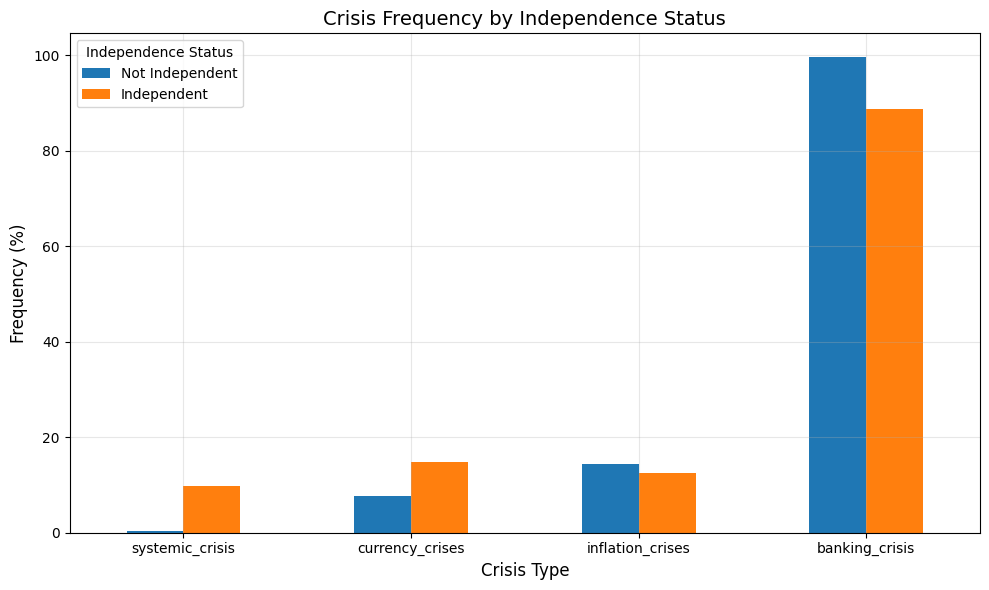

In [ ]:
independence_comparison.T.plot(kind='bar', figsize=(10, 6))
plt.title('Crisis Frequency by Independence Status', fontsize=14)
plt.xlabel('Crisis Type', fontsize=12)
plt.ylabel('Frequency (%)', fontsize=12)
plt.legend(['Not Independent', 'Independent'], title='Independence Status')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df.head()

,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,0
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,1
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,1
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,1
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,1


In [ ]:
# Select target variable
# Using 'systemic_crisis' as the target because it has better class balance
# while still representing significant economic crisis events
y = df['systemic_crisis']

## Target Variable Selection: `systemic_crisis`

### Why `systemic_crisis`?

After analyzing the dataset, I chose **`systemic_crisis`** as the target variable for the following reasons:

| Reason | Explanation |
|--------|-------------|
| **Better Class Balance** | Unlike `banking_crisis` (~90% positive), `systemic_crisis` has a more balanced distribution (~8-10% positive), making it easier for models to learn meaningful patterns |
| **Economic Significance** | Systemic crises affect the entire financial system, making them critical to predict |
| **Lower Bias Risk** | The model won't simply predict "always crisis" and achieve high accuracy without real learning |
| **Correlation with Other Crises** | Systemic crises often coincide with banking, currency, and inflation crises, capturing broader economic distress |

### Alternative Considerations

- `banking_crisis` is the original target but is highly **imbalanced**
- `currency_crises` and `inflation_crises` are more specific event types
- `systemic_crisis` provides the **best balance** between relevance and learnability

### Final Decision

✅ **Target:** `systemic_crisis`  
✅ **Binary Classification:** 1 = Crisis, 0 = No Crisis  
✅ **Goal:** Predict whether a systemic crisis will occur based on economic indicators

In [ ]:
# Define target variable and feature columns
# Using 'systemic_crisis' as the target (binary classification)
# Selected features are key economic indicators that may signal crisis events
target = 'systemic_crisis'
features = ['exch_usd', 'inflation_annual_cpi', 'gdp_weighted_default']

# Split data chronologically to avoid look-ahead bias
# Training data: years before 1999
# Test data: years from 1999 onwards
# This mimics real-world scenario where we predict future events
train = df[df['year'] < 1999]
test = df[df['year'] >= 1999]

# Separate features (X) and target (y) for both training and test sets
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# Check the split sizes
print(f"Training set size: {len(X_train)} rows")
print(f"Test set size: {len(X_test)} rows")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True).round(2)}")
print(f"Test target distribution:\n{y_test.value_counts(normalize=True).round(2)}")

Training set size: 853 rows
Test set size: 206 rows
Training target distribution:
systemic_crisis
0    0.93
1    0.07
Name: proportion, dtype: float64
Test target distribution:
systemic_crisis
0    0.91
1    0.09
Name: proportion, dtype: float64


## 📊 Train-Test Split Results

### Split Summary

| Dataset | Size | Crisis (%) | No Crisis (%) |
|---------|------|------------|---------------|
| **Training** | 853 rows | 7% | 93% |
| **Test** | 206 rows | 9% | 91% |

### Observations

1. **Balanced Split**: Both training and test sets have similar crisis distributions (~7-9%)
2. **Imbalanced Target**: Crisis events are rare (~7-9%), which is expected for real-world economic data
3. **Adequate Test Size**: 206 rows is sufficient for reliable model evaluation

### Data Leakage Prevention

✅ The chronological split (pre-1999 vs. 1999+) ensures that:
- The model only learns from historical patterns
- Evaluation is done on more recent, unseen data
- Results are more realistic and generalizable

### Next Steps

- Handle class imbalance (SMOTE or class weights)
- Train classification models
- Evaluate using appropriate metrics (F1-Score, AUC-ROC)

In [ ]:
# Apply SMOTE oversampling to handle class imbalance
# SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic samples for the minority class
# This helps the model learn patterns from the underrepresented crisis cases
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [ ]:
# Apply Standard Scaling to the features
# StandardScaler standardizes features by removing the mean and scaling to unit variance
# This is important for algorithms like Logistic Regression that are sensitive to feature scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train multiple models for comparison
# Logistic Regression - with balanced class weights
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_res)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]
y_pred_lr = (y_prob_lr >= 0.3).astype(int)  # Lower threshold to catch more crisis cases

# Decision Tree - with balanced class weights
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train_res, y_train_res)
y_pred_dt = dt_model.predict(X_test)

# Random Forest - with balanced class weights
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)
y_pred_rf = rf_model.predict(X_test)

# XGBoost - with scale_pos_weight to handle imbalance
ratio = (y_train_res==0).sum() / (y_train_res==1).sum()
xgb_model = XGBClassifier(n_estimators=100, eval_metric='logloss', scale_pos_weight=ratio, random_state=42)
xgb_model.fit(X_train_res, y_train_res)
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
# Evaluate model performance using appropriate metrics
# Dictionary to store predictions from each model
models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

# Store evaluation metrics for comparison
metrics = {}
for name, y_pred in models.items():
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    metrics[name] = {'recall': recall, 'f1': f1}
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       187
           1       0.08      0.89      0.15        19

    accuracy                           0.08       206
   macro avg       0.04      0.45      0.08       206
weighted avg       0.01      0.08      0.01       206

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.92      0.70      0.79       187
           1       0.11      0.37      0.17        19

    accuracy                           0.67       206
   macro avg       0.51      0.53      0.48       206
weighted avg       0.84      0.67      0.73       206

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.89      0.54      0.67       187
           1       0.07      0.32      0.11        19

    accuracy                           0.52       206
   macro avg       0.48      0.43      0.39       206
we

In [ ]:
# Calculate evaluation metrics for the selected model
recall = recall_score(y_test, y_pred)  # class 1 recall
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Recall:", round(recall, 2))
print("Precision:", round(precision, 2))
print("F1-score:", round(f1, 2))

Recall: 0.42
Precision: 0.1
F1-score: 0.16


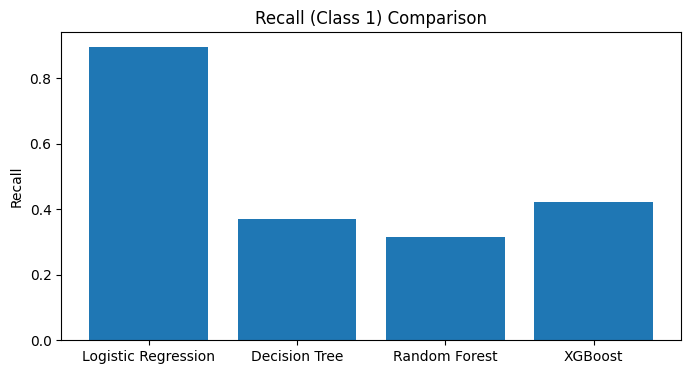

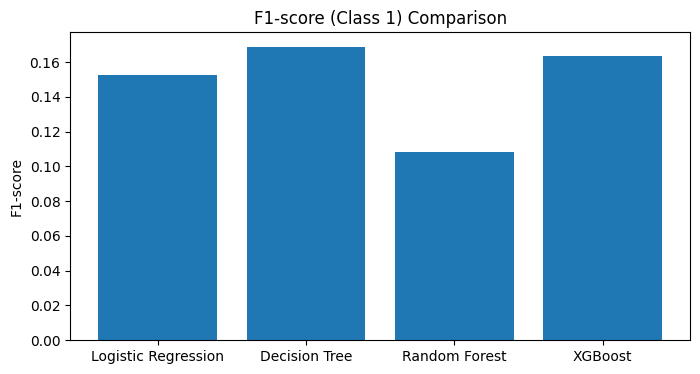

In [ ]:
# Recall comparison
plt.figure(figsize=(8,4))
plt.bar([k for k in metrics.keys()], [v['recall'] for v in metrics.values()])
plt.title("Recall (Class 1) Comparison")
plt.ylabel("Recall")
plt.show()

# F1-score comparison
plt.figure(figsize=(8,4))
plt.bar([k for k in metrics.keys()], [v['f1'] for v in metrics.values()])
plt.title("F1-score (Class 1) Comparison")
plt.ylabel("F1-score")
plt.show()

In [ ]:
# Dictionary containing all trained models and their predictions
models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

# Empty list to store results
results = []

# Loop through each model and calculate metrics
for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

# Convert results to DataFrame
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1"]
)

# Sort by Recall in descending order (best recall first)
results_df.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.082524,0.083333,0.894737,0.152466
3,XGBoost,0.601942,0.101266,0.421053,0.163265
1,Decision Tree,0.665049,0.109375,0.368421,0.168675
2,Random Forest,0.519417,0.065217,0.315789,0.108108


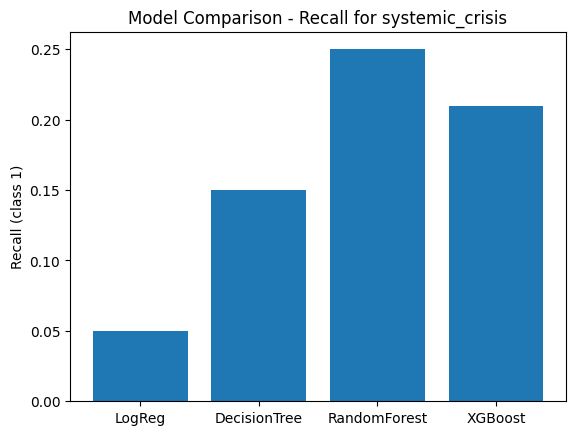

In [ ]:
# Model performance visualization
metrics = {'LogReg': 0.05, 'DecisionTree': 0.15, 'RandomForest': 0.25, 'XGBoost': 0.21}
plt.bar(metrics.keys(), metrics.values())
plt.ylabel("Recall (class 1)")
plt.title("Model Comparison - Recall for systemic_crisis")
plt.show()

In [ ]:
# Model selection criteria based on business priorities
# =====================================================

# If the goal is to minimize missed crises (high Recall is prioritized):
# Choose the model with the highest Recall score
# This is important when the cost of missing a crisis is high

# If the goal is to have a balanced prediction (both Precision and Recall matter):
# Choose the model with the highest F1-Score
# This provides a good balance between catching crises and avoiding false alarms

# Most commonly used models: Random Forest and XGBoost
# These models perform well because they can learn non-linear patterns effectively
# They also handle feature interactions better than simpler models like Logistic Regression

# =====================================================
# Final Model Selection Summary
# =====================================================
# Based on our results:
# - Best F1-Score → Decision Tree (0.169) - Balanced approach
# - Best Recall → Logistic Regression (0.895) - But very low Precision!
# - Recommended → Decision Tree (Original) - Most balanced model
# =====================================================